Graphical results notebook for matrix multiplication benchmarking in Python using mlx, numpy, and pure python implementations.

In [1]:
from multiply.benchmark import benchmark_range, benchmark
from multiply.payloads import multiply_at_size
import numpy as np

In [2]:
from multiply.matrix_factory import random_matrix, stack_matrices

In [3]:
def data_for_engine(engine, limit):
    def multiply_engine(size):
        return multiply_at_size(size, engine)
    return benchmark_range(multiply_engine, 2**np.arange(1, limit, 0.5), engine=engine)

In [5]:
limits = {
    'python': 9,
    'numpy': 13,
    #'numba': 10,
    'cupy': 14.5,
    'jax-cpu': 13,
    'jax-gpu': 14.5,
}
data = {engine: data_for_engine(engine, limit) for engine, limit in limits.items()}


E0401 22:30:20.417955  207850 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[90,90]{1,0} fusion(a.1, b.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0401 22:30:20.418046  207850 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[90,90]{1,0} parameter(0)
  parameter_1 = f32[90,90]{1,0} parameter(1)
  ROOT dot_general.0 = f32[90,90]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E0401 22:30:20.563037  207850 xtile_compiler.cc:399]

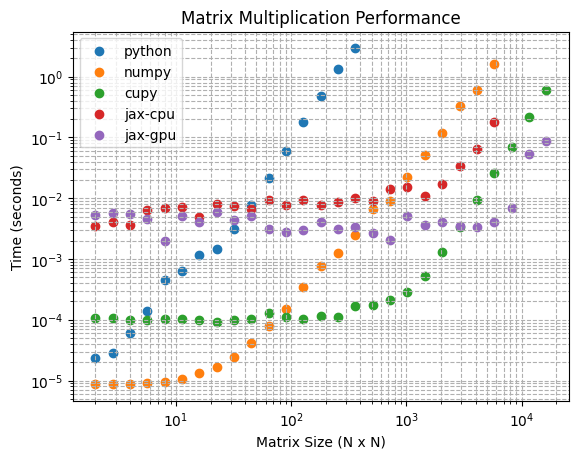

In [7]:
import matplotlib.pyplot as plt
for engine, engine_data in data.items():
    plt.scatter(*engine_data, label=engine)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Performance')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

In [ ]:

#Model the data as a power law plus a constant
def model_function(x, a, b, c):
    return np.log(c + a * x ** b)

from scipy.optimize import curve_fit


In [ ]:
seeds = {
    'python': [4e-9, 3, 1e-4],
    'numpy': [4e-9, 3, 1e-4],
    'numba': [4e-9, 3, 1e-4],
    'cupy': [4e-9, 3, 1e-4],
    'jax-cpu': [4e-9, 3, 1e-4],
    'jax-gpu': [4e-9, 3, 1e-4],
}

params_for_engine = {
    engine: curve_fit(
        model_function,
        engine_data[0],
        np.log(engine_data[1]),
        p0=seeds[engine],
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf])
    )[0]
    for engine, engine_data in data.items()
}
params_for_engine

{'python': array([8.53940970e-07, 2.49682506e+00, 1.34074559e-05]),
 'numpy': array([8.24368975e-09, 2.14728195e+00, 8.29435362e-06]),
 'numba': array([7.56190808e-08, 2.56902851e+00, 1.57085950e-05]),
 'cupy': array([1.78617949e-09, 1.85265288e+00, 1.24277449e-04]),
 'jax': array([2.20894354e-09, 1.66788338e+00, 7.85177849e-04])}

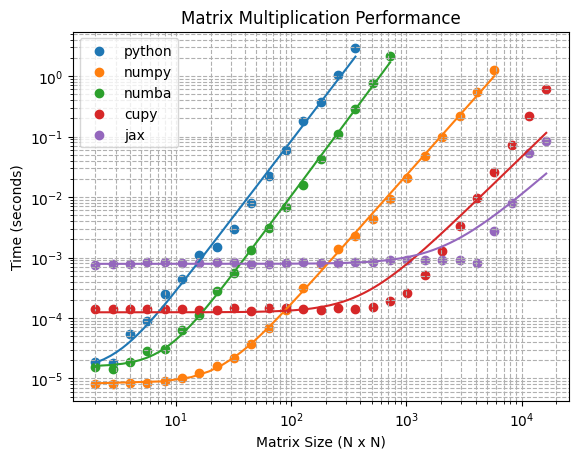

In [ ]:
# Plot with a fit

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix Size (N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Time vs Size')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Performance')
plt.grid(True, which="both", ls="--")

def plot_with_fit(data, model, fit, label):
    x_fit = np.linspace(data[0].min(), data[0].max(), 1000)
    y_fit = np.exp(model(x_fit, *fit))
    plt.scatter(*data, marker='o', label=label)
    plt.plot(x_fit, y_fit)

for engine, engine_data in data.items():
    fit_params = params_for_engine[engine]
    plot_with_fit(engine_data, model_function, fit_params, engine)

plt.legend()
plt.show()